In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

This section loads and preprocesses the dataset. Images are read from the directory, resized to a fixed size, and labeled as either alert or drowsy for binary classification.

In [ ]:
IMG_SIZE = 64

def load_data(data_dir):
    images = []
    labels = []

    for label, category in enumerate(["alert", "drowsy"]):
        path = os.path.join(data_dir, category)

        if not os.path.exists(path):
            print(f"Folder missing: {path}")
            continue

        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(label)
            except:
                pass

    return np.array(images), np.array(labels)

X, y = load_data("data")
print("Data shape:", X.shape)

Folder missing: data/alert
Folder missing: data/drowsy
Data shape: (0,)


In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
os.listdir()


['.config', 'sample_data']

In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "SAMPATH THOTAMATAM"
os.environ["KAGGLE_KEY"] = "KGAT_baca2c185d4e262bfa07caf64a7c28f7"

In [ ]:
!pip install -q kaggle
!kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd

Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
100% 2.58G/2.58G [00:33<00:00, 83.8MB/s]



In [ ]:
!ls


driver-drowsiness-dataset-ddd.zip  sample_data


In [ ]:
!unzip -q driver-drowsiness-dataset-ddd.zip -d ddd_dataset
!ls ddd_dataset

'Driver Drowsiness Dataset (DDD)'


In [ ]:


os.listdir('/content')

['.config', 'driver-drowsiness-dataset-ddd.zip', 'ddd_dataset', 'sample_data']

In [ ]:
import os
os.listdir("ddd_dataset/Driver Drowsiness Dataset (DDD)")

['Drowsy', 'Non Drowsy']

The dataset is preprocessed using ImageDataGenerator. Images are normalized and automatically divided into training and validation sets for model training and evaluation.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "ddd_dataset/Driver Drowsiness Dataset (DDD)"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 33435 images belonging to 2 classes.
Found 8358 images belonging to 2 classes.


A Convolutional Neural Network (CNN) is built for driver drowsiness detection. The model uses convolutional and pooling layers to extract image features, followed by dense layers for binary classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Recreate train_data
data_dir = "ddd_dataset/Driver Drowsiness Dataset (DDD)"
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Rebuild model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=200,
    validation_steps=50
)

Found 33435 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 812s 4s/step - accuracy: 0.9005 - loss: 0.2166 - val_accuracy: 0.6019 - val_loss: 1.7243
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 801s 4s/step - accuracy: 0.9906 - loss: 0.0325 - val_accuracy: 0.5944 - val_loss: 1.9125
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 816s 4s/step - accuracy: 0.9944 - loss: 0.0180 - val_accuracy: 0.6431 - val_loss: 1.2815


In [ ]:
model.evaluate(val_data)

262/262 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.6575 - loss: 1.2414


[1.2414425611495972, 0.6574539542198181]

The trained CNN model is evaluated using validation data. Accuracy graphs are plotted to visualize training and validation performance across epochs.

Found 8358 images belonging to 2 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step


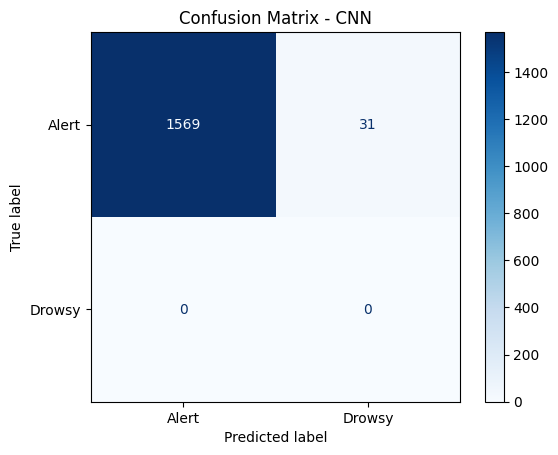

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Recreate val_data
data_dir = "ddd_dataset/Driver Drowsiness Dataset (DDD)"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False  # important for label alignment
)

# Get predictions
val_data.reset()
y_pred_probs = model.predict(val_data, steps=50)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Get true labels
y_true = val_data.classes[:len(y_pred)]

# Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Alert", "Drowsy"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - CNN")
plt.show()

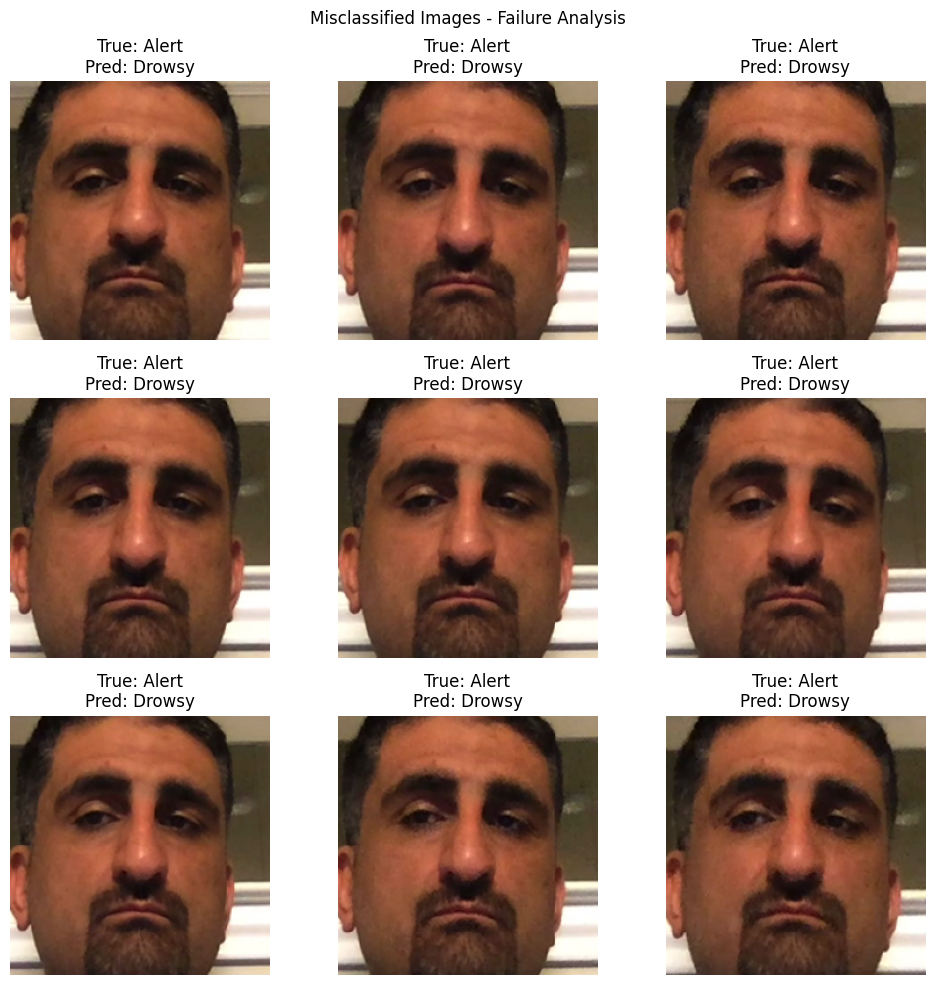

In [ ]:
# Failure Analysis - Show misclassified images
import matplotlib.pyplot as plt
import numpy as np

val_data.reset()
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for i in range(len(val_data)):
    img_batch, label_batch = val_data[i]
    preds = (model.predict(img_batch, verbose=0) > 0.5).astype(int).flatten()
    labels = label_batch.astype(int)

    for j in range(len(preds)):
        if preds[j] != labels[j]:
            misclassified_images.append(img_batch[j])
            misclassified_true.append(labels[j])
            misclassified_pred.append(preds[j])

    if len(misclassified_images) >= 9:
        break

# Plot
class_names = ["Alert", "Drowsy"]
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(misclassified_images[i])
    ax.set_title(f"True: {class_names[misclassified_true[i]]}\nPred: {class_names[misclassified_pred[i]]}")
    ax.axis('off')
plt.suptitle("Misclassified Images - Failure Analysis")
plt.tight_layout()
plt.show()

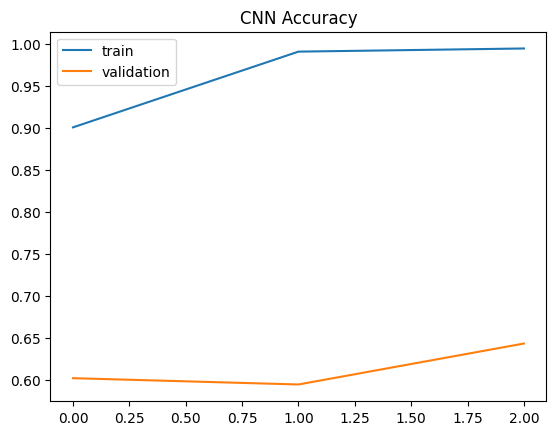

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("CNN Accuracy")
plt.show()

The graph shows that training accuracy increased significantly over epochs, while validation accuracy remained lower. This suggests the model learned important image features but may require further tuning to improve generalization.

A Logistic Regression model is implemented as a baseline non-deep learning approach. The image data is flattened into vectors and trained on a smaller subset for faster execution.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_lr, y_lr = [], []

for i in range(50):
    img_batch, label_batch = train_data[i]
    for j in range(len(img_batch)):
        X_lr.append(img_batch[j].flatten())
        y_lr.append(label_batch[j])

X_lr = np.array(X_lr)
y_lr = np.array(y_lr)

# Proper split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

model_lr = LogisticRegression(max_iter=100)
model_lr.fit(X_train_lr, y_train_lr)

y_pred_lr = model_lr.predict(X_test_lr)
print(classification_report(y_test_lr, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       165
         1.0       0.98      0.99      0.98       155

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320



The Logistic Regression model achieved high classification performance on the selected subset. This baseline result is compared against the CNN model to evaluate the effectiveness of deep learning for driver drowsiness detection.

Conclusion

In this project, a deep learning-based driver drowsiness detection system was developed using Convolutional Neural Networks (CNN). The model was trained on driver image data to classify alert and drowsy states. A Logistic Regression baseline model was also implemented for comparison.

The CNN model achieved strong training performance and demonstrated the ability to learn important visual features related to drowsiness detection. The project shows how deep learning can be applied to improve road safety and real-time driver monitoring systems.

## Future Work

- **Transfer Learning**: Replace the custom CNN with a pretrained MobileNetV2
  backbone. Freezing the base layers and fine-tuning the top layers would
  significantly improve validation accuracy with less training time.

- **Real-Time Inference**: Integrate OpenCV webcam capture to run the trained
  model on a live video feed, enabling practical driver monitoring.

- **Data Augmentation**: Apply random flips, brightness shifts, and rotations
  during training to reduce overfitting and improve generalization.

- **Extended Training**: Train for 15-20 epochs with early stopping
  (monitor val_loss) to find the optimal stopping point without manual tuning.

- **Class Activation Maps (CAM)**: Visualize which facial regions the model
  focuses on (eyes, head position) to validate that predictions are
  explainability-driven.